# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

The dataset I chose was the Flight Delay and Causes dataset from Kaggle https://www.kaggle.com/datasets/undersc0re/flight-delay-and-causes. The data includes flight level information such as departure/arrival times, origin and destination airports, delays, cancellation information, and delay cause categories (carrier delay, weather delay, National Aviation System delay, security delay, and late aircraft delay).

Who: My target audience would be airline operations managers, aiprort operation teams, or analysts responsible for reducing delays. 

What: Identify which delay types contribute most to total delays, which airports/routes appear most frequently in delayed flights, and wheteher certain times/days are associated with more delays. The goal is to support decisons on scheduling and opertional planning to reduce delays.  

How: I would start with summary charts showing distribution of arrival and departure delays to show the overall delay patterns. I would then try to create some graphs after I analyze the inital data to show any trends. 

# 3. Homework - work with your own data

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [3]:
#df_flight_dataset = pd.read_csv("flight_data.csv", encoding="latin1") #asked chatGPT for help on why sep through "," was not working
df_flight_dataset = pd.read_csv("weather_airline_delay.csv", encoding="latin1") #asked chatGPT for help on why sep through "," was not working
#df_supply_chain_dataset.head()
#I chose to limit some of the columns of data so that I could see it all when I did my code . I limited to columns that would impact delivery
print(df_flight_dataset.describe())
#adjusted the format as it would cause errors for the median, mode, and median calculations. 
#df_delivery = df_flight_dataset[["Days for shipping (real)","Days for shipment (scheduled)","Late_delivery_risk","Department Id","Order Item Quantity","Sales","Order Item Total","Product Status","shipping date (DateOrders)"]].copy()
#df_delivery["shipping date (DateOrders)"] = pd.to_datetime(df_delivery["shipping date (DateOrders)"], format='%m/%d/%Y', errors="coerce")
#df_delivery.describe()

             MONTH  DAY_OF_WEEK    DEP_DEL15  DISTANCE_GROUP  SEGMENT_NUMBER  \
count  9999.000000  9999.000000  9999.000000     9999.000000     9999.000000   
mean      6.661566     3.964996     0.194619        3.858486        3.054705   
std       3.397820     1.995037     0.395927        2.415086        1.779646   
min       1.000000     1.000000     0.000000        1.000000        1.000000   
25%       4.000000     2.000000     0.000000        2.000000        2.000000   
50%       7.000000     4.000000     0.000000        3.000000        3.000000   
75%      10.000000     6.000000     0.000000        5.000000        4.000000   
max      12.000000     7.000000     1.000000       11.000000       14.000000   

       CONCURRENT_FLIGHTS  NUMBER_OF_SEATS  AIRPORT_FLIGHTS_MONTH  \
count         9999.000000      9999.000000            9999.000000   
mean            28.226923       134.431143           12752.184518   
std             21.872565        46.212370            8890.047595   
min

Here I identify any other inconsistent data. 
Some inconsistent information I found are some of the shipping days scheduled and that are real have 0 day shipments which does not make sense. I also see a big outlier with benefit per order and order profit order with a value of -783, which I imagine should not be a negative value. I also found that there are no product descriptions and all the values in product status is 0. 

In [4]:
df_flight_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   MONTH                          9999 non-null   int64  
 1   DAY_OF_WEEK                    9999 non-null   int64  
 2   DEP_DEL15                      9999 non-null   int64  
 3   DEP_TIME_BLK                   9999 non-null   object 
 4   DISTANCE_GROUP                 9999 non-null   int64  
 5   SEGMENT_NUMBER                 9999 non-null   int64  
 6   CONCURRENT_FLIGHTS             9999 non-null   int64  
 7   NUMBER_OF_SEATS                9999 non-null   int64  
 8   CARRIER_NAME                   9999 non-null   object 
 9   AIRPORT_FLIGHTS_MONTH          9999 non-null   int64  
 10  AIRLINE_FLIGHTS_MONTH          9999 non-null   int64  
 11  AIRLINE_AIRPORT_FLIGHTS_MONTH  9999 non-null   int64  
 12  AVG_MONTHLY_PASS_AIRPORT       9999 non-null   i

In [5]:
#Identify if there are any duplicates 
#duplicate_rows = df_delivery.duplicated().sum()
#print(duplicate_rows)
#there are no duplicates within this dataset. 
df_flight_dataset.duplicated().sum()
#checked the rest of the column as well but no duplicates 

np.int64(0)

In [6]:
#Here I get the mean, median, and mode
df_flight = df_flight_dataset.drop(columns = ["CARRIER_NAME","DEPARTING_AIRPORT", "PREVIOUS_AIRPORT", "DEP_TIME_BLK"]).copy()
df_mean = df_flight.mean()
df_mean

MONTH                            6.661566e+00
DAY_OF_WEEK                      3.964996e+00
DEP_DEL15                        1.946195e-01
DISTANCE_GROUP                   3.858486e+00
SEGMENT_NUMBER                   3.054705e+00
CONCURRENT_FLIGHTS               2.822692e+01
NUMBER_OF_SEATS                  1.344311e+02
AIRPORT_FLIGHTS_MONTH            1.275218e+04
AIRLINE_FLIGHTS_MONTH            6.272816e+04
AIRLINE_AIRPORT_FLIGHTS_MONTH    3.521278e+03
AVG_MONTHLY_PASS_AIRPORT         1.599575e+06
AVG_MONTHLY_PASS_AIRLINE         7.843445e+06
FLT_ATTENDANTS_PER_PASS          1.000513e-04
GROUND_SERV_PER_PASS             1.364934e-04
PLANE_AGE                        1.160426e+01
LATITUDE                         3.669463e+01
LONGITUDE                       -9.440880e+01
PRCP                             1.045535e-01
SNOW                             3.252325e-02
SNWD                             9.291929e-02
TMAX                             7.129883e+01
AWND                             8

In [7]:
df_median = df_flight.median()
df_median

MONTH                            7.000000e+00
DAY_OF_WEEK                      4.000000e+00
DEP_DEL15                        0.000000e+00
DISTANCE_GROUP                   3.000000e+00
SEGMENT_NUMBER                   3.000000e+00
CONCURRENT_FLIGHTS               2.300000e+01
NUMBER_OF_SEATS                  1.430000e+02
AIRPORT_FLIGHTS_MONTH            1.158800e+04
AIRLINE_FLIGHTS_MONTH            7.087800e+04
AIRLINE_AIRPORT_FLIGHTS_MONTH    2.328000e+03
AVG_MONTHLY_PASS_AIRPORT         1.486066e+06
AVG_MONTHLY_PASS_AIRLINE         8.501631e+06
FLT_ATTENDANTS_PER_PASS          9.820000e-05
GROUND_SERV_PER_PASS             1.246510e-04
PLANE_AGE                        1.200000e+01
LATITUDE                         3.736300e+01
LONGITUDE                       -8.790600e+01
PRCP                             0.000000e+00
SNOW                             0.000000e+00
SNWD                             0.000000e+00
TMAX                             7.400000e+01
AWND                             7

In [8]:
df_mode = df_flight.mode()
df_mode


,MONTH,DAY_OF_WEEK,DEP_DEL15,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,AIRPORT_FLIGHTS_MONTH,AIRLINE_FLIGHTS_MONTH,AIRLINE_AIRPORT_FLIGHTS_MONTH,...,LONGITUDE,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,5,0,2,2,9,143,33994,117728,21122,...,-84.427,0.0,0.0,0.0,89,5.82,0.215945,0.187883,0.250851,0.099703


In [9]:
#Find null or na values
print(df_flight_dataset.isna().sum())
#print(df_supply_chain_dataset.isnull().sum())
#Missing values for order zipcode and product description
#converted the na values to 0 to show that they are missing values for the statistic. I did not remove the
#data as that would remove almost all the data. However for product description, it will not mattter with making those values 0 as all values were missing
df_flight_dataset.fillna(0)


MONTH                            0
DAY_OF_WEEK                      0
DEP_DEL15                        0
DEP_TIME_BLK                     0
DISTANCE_GROUP                   0
SEGMENT_NUMBER                   0
CONCURRENT_FLIGHTS               0
NUMBER_OF_SEATS                  0
CARRIER_NAME                     0
AIRPORT_FLIGHTS_MONTH            0
AIRLINE_FLIGHTS_MONTH            0
AIRLINE_AIRPORT_FLIGHTS_MONTH    0
AVG_MONTHLY_PASS_AIRPORT         0
AVG_MONTHLY_PASS_AIRLINE         0
FLT_ATTENDANTS_PER_PASS          0
GROUND_SERV_PER_PASS             0
PLANE_AGE                        0
DEPARTING_AIRPORT                0
LATITUDE                         0
LONGITUDE                        0
PREVIOUS_AIRPORT                 0
PRCP                             0
SNOW                             0
SNWD                             0
TMAX                             0
AWND                             0
CARRIER_HISTORICAL               0
DEP_AIRPORT_HIST                 0
DAY_HISTORICAL      

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,4,6,0,1000-1059,3,3,5,110,Delta Air Lines Inc.,6837,...,Atlanta Municipal,0.00,0.0,0.0,64,13.87,0.139558,0.180307,0.177124,0.147773
1,3,2,0,1000-1059,2,2,31,50,Endeavor Air Inc.,14450,...,Bangor International,0.00,0.0,0.0,48,12.08,0.155571,0.187883,0.132868,0.156045
2,2,5,0,1000-1059,8,2,37,173,United Air Lines Inc.,16530,...,Los Angeles International,0.00,0.0,0.0,54,10.07,0.189496,0.240316,0.236965,0.187484
3,4,6,0,0900-0959,11,2,37,181,Alaska Airlines Inc.,17522,...,Portland International,0.00,0.0,0.0,64,7.38,0.132326,0.112840,0.177124,0.135374
4,8,7,0,0900-0959,1,2,27,143,Southwest Airlines Co.,14220,...,Spokane International,0.00,0.0,0.0,104,4.92,0.192550,0.123487,0.196519,0.138067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,1,6,0,2200-2259,2,2,55,180,Delta Air Lines Inc.,30842,...,Raleigh-Durham International,1.22,0.0,0.0,63,9.62,0.130691,0.180153,0.144176,0.186514
9995,5,5,0,1800-1859,3,3,71,157,Delta Air Lines Inc.,25360,...,Atlanta Municipal,0.00,0.0,0.0,89,16.78,0.141341,0.172771,0.206977,0.309452
9996,8,3,0,2200-2259,1,5,12,110,Delta Air Lines Inc.,14049,...,San Francisco International,0.00,0.0,0.0,89,7.16,0.168586,0.238865,0.221672,0.283996
9997,2,5,0,1300-1359,5,3,19,181,Alaska Airlines Inc.,9017,...,Phoenix Sky Harbor International,0.00,0.0,0.0,47,6.93,0.233099,0.230231,0.236965,0.246487


In [10]:
#Using one hot encoding to adjust some of the category of data

#Adjusted the shipping mode to use ints 
unique=df_flight_dataset["CARRIER_NAME"].unique
df_flight_fixed = df_flight_dataset
one_hot = pd.get_dummies(df_flight_dataset["CARRIER_NAME"], dtype=int)
df_flight_fixed = df_flight_dataset.join(one_hot)
df_flight_fixed.iloc[0:5]

#Adjusted the delivery status to use ints 
#df_supply_fixed = df_supply_chain_dataset.drop(columns=df_supply_chain_dataset["Delivery Status"].unique(), errors="ignore")
#one_hot = pd.get_dummies(df_supply_chain_dataset["Delivery Status"], dtype=int)
#df_supply_fixed = df_supply_chain_dataset.join(one_hot)
#df_supply_fixed.iloc[0:5]




,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,Endeavor Air Inc.,Frontier Airlines Inc.,Hawaiian Airlines Inc.,JetBlue Airways,Mesa Airlines Inc.,"Midwest Airline, Inc.",SkyWest Airlines Inc.,Southwest Airlines Co.,Spirit Air Lines,United Air Lines Inc.
0,4,6,0,1000-1059,3,3,5,110,Delta Air Lines Inc.,6837,...,0,0,0,0,0,0,0,0,0,0
1,3,2,0,1000-1059,2,2,31,50,Endeavor Air Inc.,14450,...,1,0,0,0,0,0,0,0,0,0
2,2,5,0,1000-1059,8,2,37,173,United Air Lines Inc.,16530,...,0,0,0,0,0,0,0,0,0,1
3,4,6,0,0900-0959,11,2,37,181,Alaska Airlines Inc.,17522,...,0,0,0,0,0,0,0,0,0,0
4,8,7,0,0900-0959,1,2,27,143,Southwest Airlines Co.,14220,...,0,0,0,0,0,0,0,1,0,0


In [13]:
#Check for categorical imbalances

#asked google how to check the values of a column of  data with panda dataframe using python
tailnum_mode = df_flight_dataset["CARRIER_NAME"].value_counts(dropna=False)
print(tailnum_mode)
counts_taxiout = df_flight_dataset["SNOW"].value_counts(dropna=False)
print(counts_taxiout)
cancellation_code = df_flight_dataset["DEP_DEL15"].value_counts(dropna=False)
print(cancellation_code)

CARRIER_NAME
Southwest Airlines Co.          1914
Delta Air Lines Inc.            1547
American Airlines Inc.          1389
United Air Lines Inc.            966
SkyWest Airlines Inc.            870
JetBlue Airways                  431
Midwest Airline, Inc.            414
American Eagle Airlines Inc.     357
Alaska Airlines Inc.             352
Comair Inc.                      339
Endeavor Air Inc.                308
Spirit Air Lines                 288
Mesa Airlines Inc.               266
Frontier Airlines Inc.           200
Atlantic Southeast Airlines      163
Hawaiian Airlines Inc.           132
Allegiant Air                     63
Name: count, dtype: int64
SNOW
0.0    9734
0.1      47
0.3      25
1.0      18
0.8      16
0.2      16
0.6      12
0.7      11
0.5      10
1.7       8
1.5       7
1.3       7
0.9       7
1.8       6
1.1       6
3.0       6
1.2       5
2.5       5
3.8       5
3.4       4
0.4       4
2.0       4
3.1       3
2.8       3
1.6       3
2.3       2
2.4       2
3.6

Conclusion
- Are the data usable?  If not, find some new data! 
The dataset is usable for exploratory analysis of flight operations and delays. The dataset has numerous rows and columns with a mix of numeric data and string data like ariline and airports. Most columns show non-null values so no major missing data. 

- Do you need to modify or correct the data in some way?
I did not modify or correct the data but the time fileds (DepTime and ArrTime) should be adjusted to represent clock time as they are formated as an int. Based on the checks there was no missing or duplicate values. 

- Is there any class imbalance?  (Categories that have many more items than other categories).
There was some imbalance with the data I collected as I was only able to put 10000 datapoints as python was not able to handle the full dataset. The cancellationCode was almost dominated by one single value in the output showed. The TailNum alsow shoed up many times compared to other aircrafts. 

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

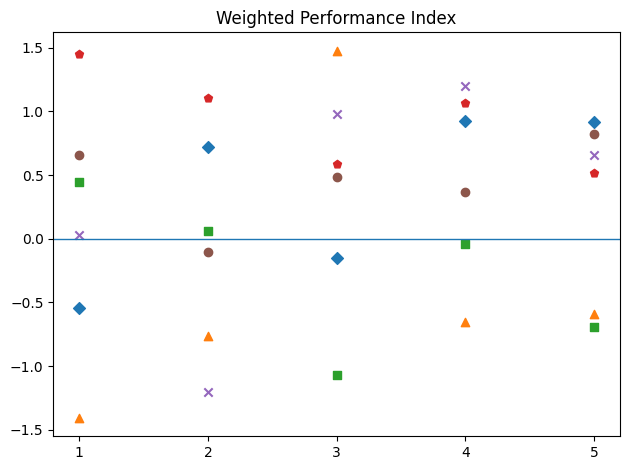

In [12]:
#I will attempt to create teh weighted performance index 

import matplotlib.pyplot as plt

competitors = ["Our Business", "Competitor A", "Competitor B", "Competitor C", "Competitor D", "Competitor E"]
categories = ["1","2","3","4","5"]
x= np.arange(len(categories))
#create arrays for each competitor

data = {
    "Our Business": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor A": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor B": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor C": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor D": np.random.uniform(-1.50, 1.50, size = 5),
    "Competitor E": np.random.uniform(-1.50, 1.50, size = 5)
} 

#Due ot this being a dictionary so I will have to separate the x and y values
x_values=[]
y_values=[]


markers = {
    "Our Business": "D",
    "Competitor A": "^",
    "Competitor B": "s",
    "Competitor C": "p",
    "Competitor D": "x",
    "Competitor E": "o"
} 


for comp, y in data.items():
    plt.scatter(x, y, marker = markers[comp], label=comp)


plt.title("Weighted Performance Index")
plt.xticks(x, categories)
plt.axhline(0, linewidth=1)
#plt.legend()

plt.tight_layout()
